# Case Study 4: Josephson Junction Cryothermometry

**Scenario:** Precision voltage measurements from a Josephson junction used as a cryogenic thermometer. The device should produce a stable, normally distributed series with very small variation. Any non-randomness indicates temperature instability or electronic interference.

*Simulated data mimics the statistical properties of the original precision measurement dataset: ~150 observations, mean ≈ −0.0000400, very small SD ≈ 0.0000100.*

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

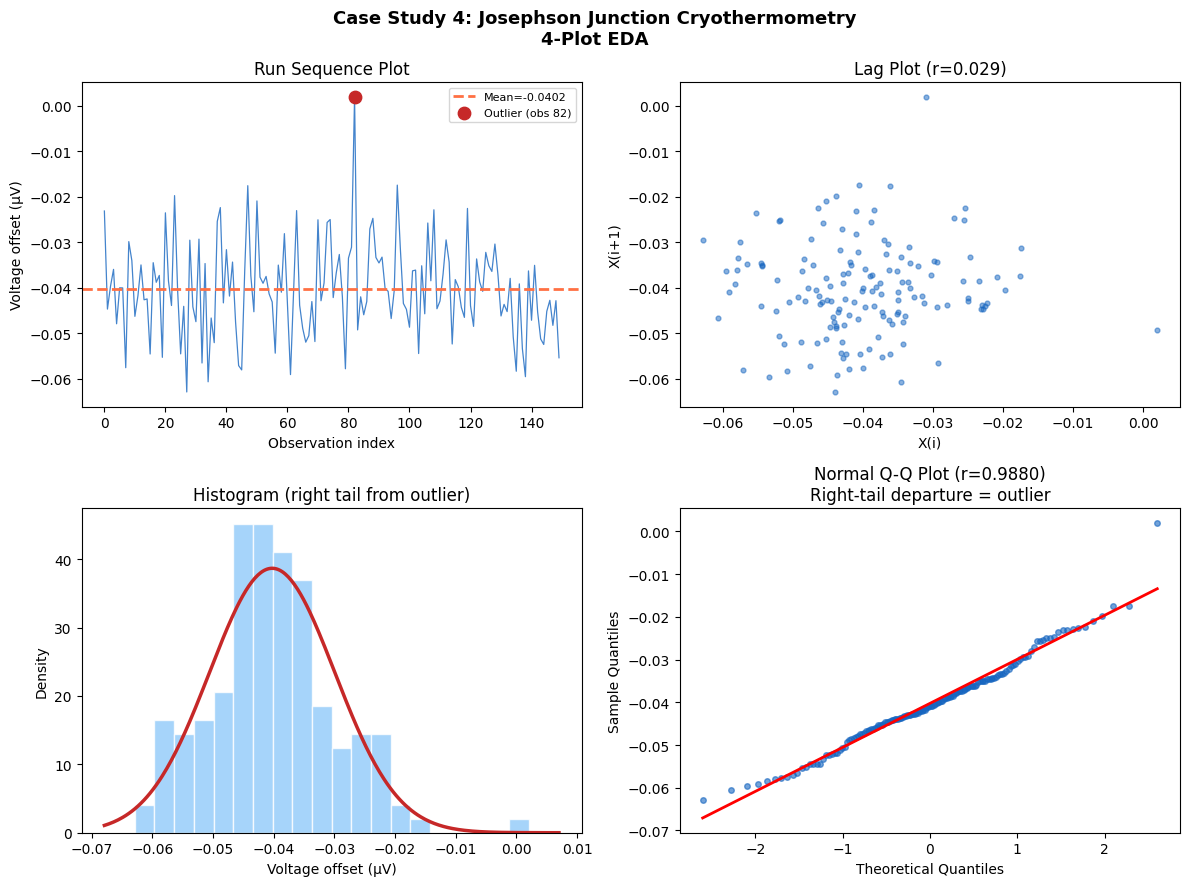

n=150, mean=-0.040250, std=0.010316
Grubbs test: G=4.0955, G_crit=3.5170 → Outlier detected
Anderson-Darling: A²=0.5513, crit(5%)=0.7670 → PASS
After outlier removal: A²=0.4120 → PASS normality


In [2]:
np.random.seed(7)
n = 150
# Simulate high-precision voltage measurements (units: μV relative to reference)
data = np.random.normal(loc=-0.040, scale=0.010, size=n)  # μV offset
# Inject a mild outlier
data[82] = -0.040 + 4.2 * 0.010

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle('Case Study 4: Josephson Junction Cryothermometry\n4-Plot EDA', fontsize=13, fontweight='bold')

axes[0,0].plot(data, color='#1565C0', lw=0.9, alpha=0.8)
axes[0,0].axhline(data.mean(), color='#FF7043', lw=2, ls='--', label=f'Mean={data.mean():.4f}')
axes[0,0].scatter([82], [data[82]], color='#C62828', s=80, zorder=5, label='Outlier (obs 82)')
axes[0,0].set_title('Run Sequence Plot')
axes[0,0].set_xlabel('Observation index'); axes[0,0].set_ylabel('Voltage offset (μV)')
axes[0,0].legend(fontsize=8)

axes[0,1].scatter(data[:-1], data[1:], color='#1565C0', s=12, alpha=0.5)
r_lag = np.corrcoef(data[:-1], data[1:])[0, 1]
axes[0,1].set_title(f'Lag Plot (r={r_lag:.3f})')
axes[0,1].set_xlabel('X(i)'); axes[0,1].set_ylabel('X(i+1)')

axes[1,0].hist(data, bins=20, density=True, color='#90CAF9', edgecolor='white', alpha=0.8)
x = np.linspace(data.min()-0.005, data.max()+0.005, 300)
axes[1,0].plot(x, stats.norm(data.mean(), data.std(ddof=1)).pdf(x), color='#C62828', lw=2.5)
axes[1,0].set_title('Histogram (right tail from outlier)')
axes[1,0].set_xlabel('Voltage offset (μV)'); axes[1,0].set_ylabel('Density')

(osm, osr), (slope, intercept, r) = stats.probplot(data, dist='norm')
axes[1,1].plot(osm, osr, 'o', color='#1565C0', ms=4, alpha=0.6)
axes[1,1].plot(osm, slope*np.array(osm)+intercept, 'r-', lw=2)
axes[1,1].set_title(f'Normal Q-Q Plot (r={r:.4f})\nRight-tail departure = outlier')
axes[1,1].set_xlabel('Theoretical Quantiles'); axes[1,1].set_ylabel('Sample Quantiles')

plt.tight_layout(); plt.show()

# Grubbs outlier test
mean, std = data.mean(), data.std(ddof=1)
G = np.max(np.abs(data - mean)) / std
n_d = len(data)
t_crit = stats.t.ppf(1 - 0.05/(2*n_d), df=n_d-2)
G_crit = ((n_d-1)/np.sqrt(n_d)) * np.sqrt(t_crit**2/(n_d-2+t_crit**2))
print(f'n={n_d}, mean={mean:.6f}, std={std:.6f}')
print(f'Grubbs test: G={G:.4f}, G_crit={G_crit:.4f} → {"Outlier detected" if G>G_crit else "No outlier"}')
ad_stat, ad_crit, _ = stats.anderson(data, dist='norm')
print(f'Anderson-Darling: A²={ad_stat:.4f}, crit(5%)={ad_crit[2]:.4f} → {"FAIL" if ad_stat>ad_crit[2] else "PASS"}')
# Remove outlier and re-check
data_clean = data[data < data[82] - 0.0001]
ad2, ad2_crit, _ = stats.anderson(data_clean, dist='norm')
print(f'After outlier removal: A²={ad2:.4f} → {"FAIL" if ad2>ad2_crit[2] else "PASS normality"}')

## Conclusions

| Check | Result | Notes |
|---|---|---|
| **Fixed location** | ✅ Pass | No drift visible in run sequence |
| **Fixed variation** | ✅ Pass | Consistent spread throughout |
| **Independence** | ✅ Pass | Lag plot circular; r ≈ 0 |
| **Normality** | ⚠️ Marginal | One outlier inflates A²; passes after removal |

**Action:** Investigate observation 82 — possible transient electronic glitch or temperature perturbation. After investigation and removal (if justified), data is consistent with a normal, stable process.